In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
import os
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from PIL import Image
from rdkit.Chem.Draw import SimilarityMaps
import os
import io


In [4]:
import smi_ted
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch
from tqdm import tqdm

TED_MODEL_NAME = "bisectgroup/materials-smi-ted-fork"
_tokenizer = AutoTokenizer.from_pretrained(TED_MODEL_NAME)
_model = AutoModel.from_pretrained(TED_MODEL_NAME)
_model.smi_ted.tokenizer = _tokenizer
_model.smi_ted.set_padding_idx_from_tokenizer()
_model.eval()

def encode(smiles_list, batch_size=128):
    embeddings = []

    if smiles_list is None or len(smiles_list) == 0:
        return np.array([])
    
    if isinstance(smiles_list, str):
        smiles_list = [smiles_list]
    
    with torch.no_grad():
        for i in tqdm(range(0, len(smiles_list), batch_size), desc="Loading Embeddings"):
            batch = smiles_list[i : i + batch_size]
            out = _model.encode(batch)
            if isinstance(out, torch.Tensor):
                if out.dim() == 3:
                    cls_vec = out[:, 0, :]
                elif out.dim() == 2:
                    cls_vec = out if out.size(0) == len(batch) else out[0, :].unsqueeze(0)
                else:
                    raise ValueError(f"Unexpected TED shape: {out.shape}")

                embeddings.append(cls_vec.cpu())
            else:
                raise ValueError("TED returned non-tensor output.")

    return torch.cat(embeddings, dim=0).numpy()
    
def decode(embeddings):
    embeddings = torch.tensor(embeddings, dtype=torch.float32)
    embeddings = embeddings.unsqueeze(0)

    _model.smi_ted.tokenizer = _tokenizer
    _model.smi_ted.set_padding_idx_from_tokenizer()
    with torch.no_grad():
        decoded_smiles = _model.decode(embeddings)
    return decoded_smiles

In [5]:
data = pd.read_csv("sol_data_organic.csv")
data.head()

,Cation,Anion,Capacity,Cation_SMILES,Anion_SMILES
0,benzyl-triphenyl-phosphonium,"(2r,3r)-2,3-dihydroxybutanedioate",2.076798,C(c1ccccc1)[P+](c2ccccc2)(c3ccccc3)c4ccccc4,O[C@H]([C@@H](O)C([O-])=O)C([O-])=O
1,benzyl-triphenyl-phosphonium,1-butanesulfonate,7.674301,C(c1ccccc1)[P+](c2ccccc2)(c3ccccc3)c4ccccc4,CCCC[S]([O-])(=O)=O
2,benzyl-triphenyl-phosphonium,1-hexanesulfonate,7.434469,C(c1ccccc1)[P+](c2ccccc2)(c3ccccc3)c4ccccc4,CCCCCC[S]([O-])(=O)=O
3,benzyl-triphenyl-phosphonium,2-(2-methoxyethoxy)ethylsulfate,1.678763,C(c1ccccc1)[P+](c2ccccc2)(c3ccccc3)c4ccccc4,COCCOCCO[S]([O-])(=O)=O
4,benzyl-triphenyl-phosphonium,"2-hydroxy-1,2,3-propanetricarboxylate",1.232528,C(c1ccccc1)[P+](c2ccccc2)(c3ccccc3)c4ccccc4,OC(CC([O-])=O)(CC([O-])=O)C([O-])=O


<Axes: >

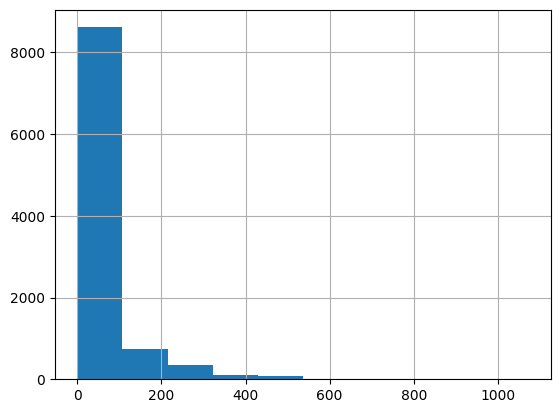

In [6]:
data['Capacity'].hist()

In [6]:
unique_cations = np.array(data['Cation'].unique())
unique_anions = np.array(data['Anion'].unique())

test_size = 0.1
val_size = 0.1

test_cations = np.random.choice(unique_cations, size=int(len(unique_cations)*test_size), replace = False)
test_anions = np.random.choice(unique_anions, size=int(len(unique_anions)*test_size), replace=False)

# remove from dataset
unique_cations = unique_cations[~np.isin(unique_cations, test_cations)]
unique_anions = unique_anions[~np.isin(unique_anions, test_anions)]

val_cations = np.random.choice(unique_cations, size=int(len(unique_cations)*val_size), replace=False)
val_anions = np.random.choice(unique_anions, size=int(len(unique_anions)*val_size), replace=False)

# remove again
unique_cations = unique_cations[~np.isin(unique_cations, val_cations)]
unique_anions = unique_anions[~np.isin(unique_anions, val_anions)]
train_cations = unique_cations
train_anions = unique_anions

train_data = data[data['Cation'].isin(train_cations) & data['Anion'].isin(train_anions)]
test_data = data[data['Cation'].isin(test_cations) & data['Anion'].isin(test_anions)]
val_data = data[data['Cation'].isin(val_cations) & data['Anion'].isin(val_anions)]

print(f"Train data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")
print(f"Validation data size: {len(val_data)}")

train_c_set = set(train_data['Cation'])
train_a_set = set(train_data['Anion'])
test_c_set = set(test_data['Cation'])
test_a_set = set(test_data['Anion'])
val_c_set = set(val_data['Cation'])
val_a_set = set(val_data['Anion'])

print("intersection of cations (train and test):", train_c_set.intersection(test_c_set))
print("intersection of anions (train and test):", train_a_set.intersection(test_a_set))
print("intersection of cations (train and val):", train_c_set.intersection(val_c_set))
print("intersection of anions (train and val):", train_a_set.intersection(val_a_set))

Train data size: 6600
Test data size: 96
Validation data size: 70
intersection of cations (train and test): set()
intersection of anions (train and test): set()
intersection of cations (train and val): set()
intersection of anions (train and val): set()


In [ ]:
train_c_features = encode(train_data['Cation_SMILES'])
train_a_features = encode(train_data['Anion_SMILES'])
test_c_features = encode(test_data['Cation_SMILES'])
test_a_features = encode(test_data['Anion_SMILES'])
val_c_features = encode(val_data['Cation_SMILES'])
val_a_features = encode(val_data['Anion_SMILES'])

X_train = np.hstack((train_c_features, train_a_features))
y_train = train_data['Capacity'].apply(lambda x: np.log10(x) if x > 0 else 0).values

X_test = np.hstack((test_c_features, test_a_features))
y_test = test_data['Capacity'].apply(lambda x: np.log10(x) if x > 0 else 0).values

X_val = np.hstack((val_c_features, val_a_features))
y_val = val_data['Capacity'].apply(lambda x: np.log10(x) if x > 0 else 0).values

Loading Embeddings: 100%|██████████| 1/1 [00:00<00:00, 15.27it/s]


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

class SolubilityModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.cation_encoder = nn.Linear(input_dim//2, hidden_dim)
        self.anion_encoder = nn.Linear(input_dim//2, hidden_dim)
        
        # Cross-attention to model interactions
        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)
        
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    def forward(self, x):
        # Split into cation and anion
        cation_emb = self.cation_encoder(x[:, :x.shape[1]//2])
        anion_emb = self.anion_encoder(x[:, x.shape[1]//2:])
        
        # Add batch dimension for attention
        cation_emb = cation_emb.unsqueeze(1)  # [batch, 1, hidden]
        anion_emb = anion_emb.unsqueeze(1)
        
        # Cross-attention: how cation attends to anion
        attn_out, _ = self.cross_attn(cation_emb, anion_emb, anion_emb)
        
        # Combine
        combined = torch.cat([attn_out.squeeze(1), anion_emb.squeeze(1)], dim=1)
        
        x = self.relu(self.fc1(combined))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x).cpu().numpy()

model.compile()

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    model.to(device)
    losses = []

    for epoch in range(num_epochs):
        model.train()
        train_total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_total_loss += loss.item() * X_batch.size(0)

        model.eval()
        val_total_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                val_total_loss += loss.item() * X_batch.size(0)

        train_loss = train_total_loss / len(train_loader.dataset)
        val_loss = val_total_loss / len(val_loader.dataset)

        epoch_losses = {
            "train_loss": train_loss,
            "val_loss": val_loss
        }
        losses.append(epoch_losses)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return losses, model


Epoch 1/5, Loss: 0.7848, Val Loss: 0.5857
Epoch 2/5, Loss: 0.2901, Val Loss: 0.4524
Epoch 3/5, Loss: 0.1166, Val Loss: 0.0695
Epoch 4/5, Loss: 0.0664, Val Loss: 0.0888
Epoch 5/5, Loss: 0.0475, Val Loss: 0.0583


In [11]:
def create_zero_shot_split(data, test_ratio=0.1, seed=None):
    np.random.seed(seed)
    unique_cations = data['Cation'].unique()
    unique_anions = data['Anion'].unique()
    
    test_cations = np.random.choice(unique_cations, size=int(len(unique_cations)*test_size), replace = False)
    test_anions = np.random.choice(unique_anions, size=int(len(unique_anions)*test_size), replace=False)

    # remove from dataset
    unique_cations = unique_cations[~np.isin(unique_cations, test_cations)]
    unique_anions = unique_anions[~np.isin(unique_anions, test_anions)]

    val_cations = np.random.choice(unique_cations, size=int(len(unique_cations)*val_size), replace=False)
    val_anions = np.random.choice(unique_anions, size=int(len(unique_anions)*val_size), replace=False)

    # remove again
    unique_cations = unique_cations[~np.isin(unique_cations, val_cations)]
    unique_anions = unique_anions[~np.isin(unique_anions, val_anions)]
    train_cations = unique_cations
    train_anions = unique_anions

    train_data = data[data['Cation'].isin(train_cations) & data['Anion'].isin(train_anions)]
    test_data = data[data['Cation'].isin(test_cations) & data['Anion'].isin(test_anions)]
    val_data = data[data['Cation'].isin(val_cations) & data['Anion'].isin(val_anions)]

    train_c_features = encode(train_data['Cation_SMILES'].tolist())
    train_a_features = encode(train_data['Anion_SMILES'].tolist())
    test_c_features = encode(test_data['Cation_SMILES'].tolist())
    test_a_features = encode(test_data['Anion_SMILES'].tolist())
    val_c_features = encode(val_data['Cation_SMILES'].tolist())
    val_a_features = encode(val_data['Anion_SMILES'].tolist())

    X_train = np.hstack((train_c_features, train_a_features))
    y_train = train_data['Capacity'].apply(lambda x: np.log10(x) if x > 0 else 0).values

    X_test = np.hstack((test_c_features, test_a_features))
    y_test = test_data['Capacity'].apply(lambda x: np.log10(x) if x > 0 else 0).values

    X_val = np.hstack((val_c_features, val_a_features))
    y_val = val_data['Capacity'].apply(lambda x: np.log10(x) if x > 0 else 0).values
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

    return train_loader, test_loader, val_loader


In [ ]:
input_dim = X_train.shape[1]

num_epochs = 5
device = 'cuda:0'
# Train multiple models with different splits
models = []
for seed in range(5):
    train, test, val = create_zero_shot_split(data, seed=seed)
    
    model = SolubilityModel(input_dim, hidden_dim=32)
    criterion = nn.MSELoss()

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    _, model = train_model(model, train, val, criterion, optimizer, num_epochs, device)
    models.append(model)
    
# Ensemble predictions
def ensemble_predict(models, X):
    preds = [model.predict(X) for model in models]
    return np.mean(preds, axis=0)

In [8]:
# prediction on test set
model.eval()
predictions = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch).squeeze()
        predictions.extend(outputs.cpu().numpy())

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
print(f"Test R2: {r2:.4f}, Test MSE: {mse:.4f}")

Test R2: 0.6814, Test MSE: 0.1999


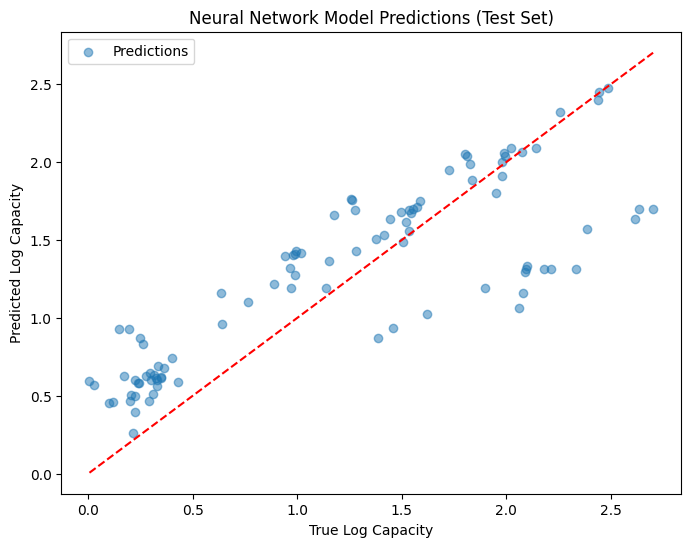

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Log Capacity')
plt.ylabel('Predicted Log Capacity')
plt.title('Neural Network Model Predictions (Test Set)')
plt.legend()
plt.show()

In [10]:
from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem import Draw

def get_brics_fragments_with_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)

    # Break BRICS bonds
    bonds = BRICS.FindBRICSBonds(mol)
    bond_indices = [mol.GetBondBetweenAtoms(a,b).GetIdx() for (a,b),_ in bonds]

    frag_mol = Chem.FragmentOnBonds(mol, bond_indices, addDummies=True)

    frags = Chem.GetMolFrags(
        frag_mol,
        asMols=False,          # gives atom index mapping
        sanitizeFrags=False
    )

    return mol, frags

def mask_fragment(mol, atom_indices):
    rw = Chem.RWMol(mol)

    for idx in atom_indices:
        atom = rw.GetAtomWithIdx(idx)
        atom.SetAtomicNum(6)   # carbon mask
        atom.SetFormalCharge(0)
        atom.SetIsAromatic(False)

        # remove special features
        atom.SetNumExplicitHs(0)

    masked = rw.GetMol()
    Chem.SanitizeMol(masked)

    return masked

    
def fragment_contributions(smiles, partner_smiles, model, is_cation=True):

    mol, frags = get_brics_fragments_with_atoms(smiles)

    ref_input = np.hstack((encode([smiles]),
                           encode([partner_smiles])))
    ref_pred = model.predict(ref_input.reshape(1,-1))[0]

    contribs = []

    for frag_atoms in frags:

        masked = mask_fragment(mol, frag_atoms)
        masked_smiles = Chem.MolToSmiles(masked)

        if is_cation:
            inp = np.hstack((encode([masked_smiles]),
                             encode([partner_smiles])))
        else:
            inp = np.hstack((encode([partner_smiles]),
                             encode([masked_smiles])))

        new_pred = model.predict(inp.reshape(1,-1))[0]

        contrib = ref_pred - new_pred   # intuitive sign

        contribs.append({
            "atoms": frag_atoms,
            "score": float(contrib)
        })

    return contribs

def fragment_to_atom_scores(mol, frag_contribs):

    atom_scores = np.zeros(mol.GetNumAtoms())
    counts = np.zeros(mol.GetNumAtoms())

    for frag in frag_contribs:
        score = frag["score"]

        for idx in frag["atoms"]:
            atom_scores[idx] += score
            counts[idx] += 1

    counts[counts == 0] = 1
    atom_scores /= counts

    return atom_scores

def visualize_fragment_contributions(smiles, contribs):
    """
    Visualize fragment contributions using RDKit's SimilarityMaps.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Map contributions to atoms
    atom_contribs = [0.0] * mol.GetNumAtoms()
    atom_counts = [0] * mol.GetNumAtoms()
    
    for frag_smiles, score in contribs.items():
        frag_mol = Chem.MolFromSmiles(frag_smiles)
        if frag_mol is None:
            continue
        matches = mol.GetSubstructMatches(frag_mol)
        for match in matches:
            for atom_idx in match:
                atom_contribs[atom_idx] += score
                atom_counts[atom_idx] += 1
    
    # Average and normalize
    atom_contribs = [
        contrib / count if count > 0 else 0 
        for contrib, count in zip(atom_contribs, atom_counts)
    ]

    max_contrib = max(abs(c) for c in atom_contribs) or 1
    norm_contribs = [c / max_contrib for c in atom_contribs]

    # Use RDKit SimilarityMap with Cairo drawer
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)
    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        norm_contribs,
        colorMap='coolwarm',
        contourLines=10,
        alpha=0.5,
        draw2d=drawer
    )
    drawer.FinishDrawing()

    # Convert to image
    png = drawer.GetDrawingText()
    
    img = Image.open(io.BytesIO(png))

    # plt.imshow(img)
    # plt.axis('off')
    # plt.title(f'Fragment Contribution Heatmap\n{smiles}', pad=20)
    # plt.tight_layout()
    # plt.show()

    return atom_contribs, img

# smiles_cation = top_entries.iloc[0]['Cation_SMILES']
# smiles_anion = top_entries.iloc[0]['Anion_SMILES']
# print("Cation SMILES:", smiles_cation)
# print("Anion SMILES:", smiles_anion)
# contrib_cation, contrib_anion = get_frag_contribs(smiles_cation, smiles_anion, xgb_model)
# print("Cation Fragment Contributions:", contrib_cation)
# print("Anion Fragment Contributions:", contrib_anion)

In [11]:
sorted_data = data.sort_values(by='Capacity', ascending=False)
groupby_cation = sorted_data.groupby('Cation')
groupby_anion = sorted_data.groupby('Anion')

visited_cations = set()
visited_anions = set()

cation_samples = []
anion_samples = []
n_samples = 1
for name, group in groupby_cation:
    if name not in visited_cations:
        for i in range(min(n_samples, len(group))):
            cation_samples.append(group.iloc[i])
        visited_cations.add(name)
for name, group in groupby_anion:
    if name not in visited_anions:
        for i in range(min(n_samples, len(group))):
            anion_samples.append(group.iloc[i])
        visited_anions.add(name)

cation_samples_df = pd.DataFrame(cation_samples)
anion_samples_df = pd.DataFrame(anion_samples)

combined_samples_df = pd.concat([cation_samples_df, anion_samples_df]).drop_duplicates(subset=['Cation', 'Anion']).reset_index(drop=True)

print(combined_samples_df.shape)
display(combined_samples_df.head(10))

(222, 5)


,Cation,Anion,Capacity,Cation_SMILES,Anion_SMILES
0,(2-ethoxyethyl)-ethyl-dimethylammonium,acetate,286.01580,CCOCC[N+](C)(C)CC,CC([O-])=O
1,"1,1-dihexylpyrrolidinium",propanoate,465.91840,CCCCCC[N+]1(CCCCCC)CCCC1,CCC([O-])=O
2,"1,1-dimethyl-pyrrolidinium",acetate,331.54580,C[N+]1(C)CCCC1,CC([O-])=O
3,"1,1-dipropyl-pyrrolidinium",propanoate,568.36410,CCC[N+]1(CCC)CCCC1,CCC([O-])=O
4,"1,3-bis[(heptyloxy)methyl]-imidazolium",acetate,50.88509,CCCCCCCOCn1cc[n+](COCCCCCCC)c1,CC([O-])=O
5,"1,3-didecyl-2-methyl-imidazolium",propanoate,240.99970,CCCCCCCCCCn1cc[n+](CCCCCCCCCC)c1C,CCC([O-])=O
6,"1,3-diethylimidazolium",acetate,175.51190,CCn1cc[n+](CC)c1,CC([O-])=O
7,"1,3-dihexyl-imidazolium",acetate,150.84820,CCCCCCn1cc[n+](CCCCCC)c1,CC([O-])=O
8,"1,3-dimethyl-3H-imidazol-1-ium",acetate,156.72010,Cn1cc[n+](C)c1,CC([O-])=O
9,"1,3-dipentyl-imidazolium",acetate,159.62040,CCCCCn1cc[n+](CCCCC)c1,CC([O-])=O


In [ ]:
import warnings
from tqdm import tqdm
import rdkit
rdkit.RDLogger.DisableLog('rdApp.*')  # Disable RDKit warnings
warnings.filterwarnings("ignore")

os.makedirs('./fragment_contribs_smi', exist_ok=True)

frag_contrib_path = './fragment_contribs_smi'
frag_contribs_list = []
for index, entry in tqdm(combined_samples_df.iterrows(), total=combined_samples_df.shape[0], desc="Calculating fragment contributions"):
    smiles_cation = entry['Cation_SMILES']
    smiles_anion = entry['Anion_SMILES']
    cation_label = f"Cation: {entry['Cation']}"
    capacity = entry['Capacity']
    contribs_cation = fragment_contributions(smiles_cation, smiles_anion, model, is_cation=True)
    contribs_anion = fragment_contributions(smiles_anion, smiles_cation, model, is_cation=False)

    cation_contribs, img_cation = visualize_fragment_contributions(smiles_cation, contribs_cation)
    anion_contribs, img_anion = visualize_fragment_contributions(smiles_anion, contribs_anion)
    
    frag_contribs_list.append({
        'Cation': entry['Cation'],
        'Anion': entry['Anion'],
        'Cation_Contribs': contribs_cation,
        'Anion_Contribs': contribs_anion
    })

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(img_cation)
    ax[0].axis('off')
    ax[0].set_title(f"{cation_label}")
    ax[1].imshow(img_anion)
    ax[1].axis('off')
    ax[1].set_title(f"Anion: {entry['Anion']}")
    fig.suptitle('Fragment Contribution Heatmaps', fontsize=16)
    fig.text(0.5, 0.04, f'True log(Capacity): {np.log10(capacity):.2f}', ha='center', fontsize=12)
    plt.savefig(os.path.join(frag_contrib_path, f'{entry["Cation"]}_{entry["Anion"]}_fragment_contrib.png'))
    plt.close()

frag_contribs_df = pd.DataFrame(frag_contribs_list)
frag_contribs_df.to_csv('fragment_contributions_smi.csv', index=False)